# Capital Timing Trap: Promo Budget Should Fund Peak Inventory Readiness

This notebook is not a pricing analysis.

Promotion is treated as a mistimed capital pool and symptom, not the main diagnosis. The main diagnosis is seasonal capital misallocation: discount capital is deployed in off-peak periods where demand is weak, while Apr-Jun has stronger natural demand and observed inventory constraints.

Forecasting is the operating system for reallocating capital before peak demand. The decision system is: identify positive-margin category/SKU candidates with observed peak stockout occurrence, forecast-supported Apr-Jun demand, and high gross profit per inventory VND; then redirect weak off-peak promo budget into pre-peak inventory readiness.


In [1]:
# CELL 0 - Setup + Load + Fact Table

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

ROOT = Path.cwd()
while ROOT.name != "VinDatathon_the-4-Outliers" and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if ROOT.name != "VinDatathon_the-4-Outliers":
    raise RuntimeError("Cannot locate repo root. Run notebook from inside VinDatathon_the-4-Outliers/")

CLEAN = ROOT / "data" / "clean"
OUT = ROOT / "outputs"
OUT.mkdir(exist_ok=True)

import sys
sys.path.insert(0, str(ROOT))

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display, Markdown

from theme import (
    apply_theme, style_ax, COLORS,
    annotate_bar, add_insight, make_legend,
    CLR_SPINE, CLR_LABEL, CLR_MUTED, SEQ_BLUE
)
apply_theme()

# Load clean parquet tables.
order_items = pd.read_parquet(CLEAN / 'order_items.parquet')
orders = pd.read_parquet(CLEAN / 'orders.parquet')
products = pd.read_parquet(CLEAN / 'products.parquet')
sales = pd.read_parquet(CLEAN / 'sales.parquet')
payments = pd.read_parquet(CLEAN / 'payments.parquet')
promotions = pd.read_parquet(CLEAN / 'promotions.parquet')
web_traffic = pd.read_parquet(CLEAN / 'web_traffic.parquet')
inventory = pd.read_parquet(CLEAN / 'inventory.parquet')

loaded = pd.DataFrame({
    'table': ['order_items', 'orders', 'products', 'sales', 'payments', 'promotions', 'web_traffic', 'inventory'],
    'rows': [len(order_items), len(orders), len(products), len(sales), len(payments), len(promotions), len(web_traffic), len(inventory)],
    'columns': [order_items.shape[1], orders.shape[1], products.shape[1], sales.shape[1], payments.shape[1], promotions.shape[1], web_traffic.shape[1], inventory.shape[1]],
})
display(loaded)

# Build line-level economics fact table.
oi = order_items.merge(
    orders[['order_id','order_date','order_status','customer_id']],
    on='order_id'
)
oi = oi.merge(
    products[['product_id','cogs','segment','category']],
    on='product_id',
    how='left'
)

oi['discount_amount'] = oi['discount_amount'].fillna(0)
oi['line_revenue'] = oi['quantity'] * oi['unit_price']
oi['net_line'] = oi['line_revenue'] - oi['discount_amount']
oi['cogs_line'] = oi['quantity'] * oi['cogs']
oi['gross_profit'] = oi['net_line'] - oi['cogs_line']
# B-BIS fulfilled/committed basis: exclude cancelled/created; returned still counts
# because inventory and COGS have already left the business. Refunds are handled
# separately in realized_cash_after_refund, not in this notebook's margin basis.
oi['is_committed'] = ~oi['order_status'].isin(['cancelled', 'created'])
oi['is_fulfilled'] = oi['is_committed']  # backward-compatible alias for B-BIS wording
oi['has_promo'] = (
    (oi['discount_amount'] > 0)
    | oi['promo_id'].fillna('No_Promo').ne('No_Promo')
    | oi['promo_id_2'].notna()
)
oi['date'] = pd.to_datetime(oi['order_date']).dt.normalize()
oi['year'] = oi['date'].dt.year
oi['month'] = oi['date'].dt.month
oi['is_peak'] = oi['month'].isin([4, 5, 6])

f = oi[oi['is_committed']].copy()

# Prepare inventory, using stockout occurrence as observed evidence.
inv = inventory.copy()
inv['snapshot_date'] = pd.to_datetime(inv['snapshot_date'])
inv['month'] = inv['snapshot_date'].dt.month
inv['year'] = inv['snapshot_date'].dt.year
inv['is_peak'] = inv['month'].isin([4, 5, 6])

if 'category' not in inv.columns:
    inv = inv.merge(products[['product_id', 'category']], on='product_id', how='left')

required_inventory_cols = {
    'stockout_days', 'stockout_flag', 'fill_rate',
    'units_sold', 'stock_on_hand', 'year', 'month'
}
missing_inventory_cols = sorted(required_inventory_cols - set(inv.columns))
assert not missing_inventory_cols, f"Missing inventory columns: {missing_inventory_cols}"

print(f"Fact rows: {len(oi):,} total lines | {len(f):,} committed/fulfilled lines (B-BIS; returned included)")
print(f"Date range: {oi['date'].min().date()} to {oi['date'].max().date()}")
print("Promo definition: discount_amount > 0 OR promo_id != 'No_Promo' OR promo_id_2 present")


Vivid Slate theme applied.


,table,rows,columns
0,order_items,714669,7
1,orders,646945,8
2,products,2412,8
3,sales,3833,3
4,payments,646945,4
5,promotions,50,10
6,web_traffic,3652,7
7,inventory,60247,17


Fact rows: 714,669 total lines | 641,002 committed/fulfilled lines (B-BIS; returned included)
Date range: 2012-07-04 to 2022-12-31
Promo definition: discount_amount > 0 OR promo_id != 'No_Promo' OR promo_id_2 present


In [2]:
# CELL 1 - Reconciliation Assert

# Run before all analysis. If this fails, stop the notebook.
tol = 1_000

assert abs(oi['line_revenue'].sum() - sales['Revenue'].sum()) < tol,     f"Gross mismatch: {oi['line_revenue'].sum():,.0f} vs {sales['Revenue'].sum():,.0f}"

assert abs(oi['net_line'].sum() - payments['payment_value'].sum()) < tol,     f"Net mismatch: {oi['net_line'].sum():,.0f} vs {payments['payment_value'].sum():,.0f}"

assert abs(oi['cogs_line'].sum() - sales['COGS'].sum()) < tol,     f"COGS mismatch: {oi['cogs_line'].sum():,.0f} vs {sales['COGS'].sum():,.0f}"

print("✓ Reconciliation passed")
print(f"Gross booked:  {oi['line_revenue'].sum()/1e9:.3f}B VND")
print(f"Net paid:      {oi['net_line'].sum()/1e9:.3f}B VND")
print(f"Discount burn: {(oi['line_revenue'].sum()-oi['net_line'].sum())/1e6:.1f}M VND")
print(f"COGS total:    {oi['cogs_line'].sum()/1e9:.3f}B VND")


✓ Reconciliation passed
Gross booked:  16.430B VND
Net paid:      15.681B VND
Discount burn: 749.6M VND
COGS total:    14.163B VND


In [3]:
# CELL 2 - KPI Contract Table

# Margin basis: (net_line - cogs_line) / net_line * 100 after B-BIS committed/fulfilled filter.
period = f.groupby('is_peak').agg(
    net_sales=('net_line', 'sum'),
    discount_burn=('discount_amount', 'sum'),
    gross_profit=('gross_profit', 'sum'),
    promo_rate=('has_promo', 'mean'),
    orders=('order_id', 'nunique'),
    customers=('customer_id', 'nunique'),
    days=('date', 'nunique')
).reset_index()

period['net_sales_per_day'] = period['net_sales'] / period['days']
period['discount_per_day'] = period['discount_burn'] / period['days']
period['net_margin'] = period['gross_profit'] / period['net_sales'] * 100
period['period'] = np.where(period['is_peak'], 'Peak Apr-Jun', 'Off-peak')
period = period.sort_values('is_peak', ascending=False).reset_index(drop=True)

peak_period = period.loc[period['is_peak']].iloc[0]
off_period = period.loc[~period['is_peak']].iloc[0]
revenue_day_ratio = peak_period['net_sales_per_day'] / off_period['net_sales_per_day']

period_display = period.assign(
    promo_rate=lambda d: d['promo_rate'].map(lambda x: f"{x:.1%}"),
    net_sales=lambda d: d['net_sales'].map(lambda x: f"{x/1e9:.3f}B VND"),
    discount_burn=lambda d: d['discount_burn'].map(lambda x: f"{x/1e6:.1f}M VND"),
    gross_profit=lambda d: d['gross_profit'].map(lambda x: f"{x/1e6:.1f}M VND"),
    net_sales_per_day=lambda d: d['net_sales_per_day'].map(lambda x: f"{x/1e6:.2f}M VND"),
    discount_per_day=lambda d: d['discount_per_day'].map(lambda x: f"{x/1e6:.3f}M VND"),
    net_margin=lambda d: d['net_margin'].map(lambda x: f"{x:.2f}%"),
)

cols = [
    'period', 'promo_rate', 'net_sales', 'net_sales_per_day',
    'discount_burn', 'discount_per_day', 'gross_profit',
    'net_margin', 'orders', 'customers', 'days'
]
display(period_display[cols])

contract = pd.DataFrame({
    'KPI': [
        'Revenue/day ratio',
        'Peak promo rate',
        'Off-peak promo rate',
        'Off-peak discount burn',
        'Margin basis',
        'Report headline basis'
    ],
    'Computed value': [
        f"{revenue_day_ratio:.2f}×",
        f"{peak_period['promo_rate']:.1%}",
        f"{off_period['promo_rate']:.1%}",
        f"{off_period['discount_burn']/1e6:.1f}M VND",
        '(net_line - cogs_line) / net_line, B-BIS committed/fulfilled',
        'Cell 3B K3-compatible monthly/gross basis'
    ],
    'Basis': [
        'Peak net committed revenue/day divided by off-peak',
        'B-BIS committed line-weighted has_promo mean',
        'B-BIS committed line-weighted has_promo mean',
        'B-BIS committed off-peak discount_amount sum',
        'Discount-aware margin, excluding cancelled/created and including returned; refunds are separate',
        'Used only for report prose headline numbers to match business_eda/K3 references'
    ]
})
display(contract)
print("Operational KPI contract uses current clean parquet; report headline basis is cross-referenced in Cell 3B.")


,period,promo_rate,net_sales,net_sales_per_day,discount_burn,discount_per_day,gross_profit,net_margin,orders,customers,days
0,Peak Apr-Jun,23.7%,5.148B VND,5.66M VND,157.2M VND,0.173M VND,756.3M VND,14.69%,197679,63206,910
1,Off-peak,46.2%,8.904B VND,3.05M VND,514.7M VND,0.176M VND,604.8M VND,6.79%,382529,77173,2923


,KPI,Computed value,Basis
0,Revenue/day ratio,1.86×,Peak net committed revenue/day divided by off-...
1,Peak promo rate,23.7%,B-BIS committed line-weighted has_promo mean
2,Off-peak promo rate,46.2%,B-BIS committed line-weighted has_promo mean
3,Off-peak discount burn,514.7M VND,B-BIS committed off-peak discount_amount sum
4,Margin basis,"(net_line - cogs_line) / net_line, B-BIS commi...","Discount-aware margin, excluding cancelled/cre..."
5,Report headline basis,Cell 3B K3-compatible monthly/gross basis,Used only for report prose headline numbers to...


Operational KPI contract uses current clean parquet; report headline basis is cross-referenced in Cell 3B.


In [4]:
# CELL 3 - Statistical Check

# Daily table for statistical checks.
daily = f.groupby('date').agg(
    net_rev=('net_line', 'sum'),
    discount_burn=('discount_amount', 'sum'),
    promo_rate=('has_promo', 'mean'),
    orders=('order_id', 'nunique'),
    customers=('customer_id', 'nunique')
).reset_index()

daily['month'] = daily['date'].dt.month
daily['is_peak'] = daily['month'].isin([4, 5, 6])

wt = web_traffic.copy()
wt['date'] = pd.to_datetime(wt['date']).dt.normalize()
daily = daily.merge(wt[['date', 'sessions']], on='date', how='left')

peak_daily = daily[daily['is_peak']]
off_daily = daily[~daily['is_peak']]
peak_promo_rate = peak_daily['promo_rate'].mean()
offpeak_promo_rate = off_daily['promo_rate'].mean()
revenue_day_ratio_daily = peak_daily['net_rev'].mean() / off_daily['net_rev'].mean()

if 'sessions' in daily and daily['sessions'].notna().any():
    sessions_day_ratio = peak_daily['sessions'].mean() / off_daily['sessions'].mean()
else:
    sessions_day_ratio = np.nan

r_all = daily['promo_rate'].corr(daily['net_rev'])
r_off = off_daily['promo_rate'].corr(off_daily['net_rev'])

try:
    from scipy.stats import ttest_ind
    t_stat, p_val = ttest_ind(
        daily.loc[~daily['is_peak'], 'promo_rate'].dropna(),
        daily.loc[daily['is_peak'], 'promo_rate'].dropna(),
        equal_var=False
    )
except ImportError:
    t_stat, p_val = np.nan, np.nan

stat_check = pd.DataFrame({
    'Metric': [
        'Peak daily promo rate',
        'Off-peak daily promo rate',
        'Peak/off-peak revenue per day',
        'Peak/off-peak sessions per day',
        'corr(promo_rate, net_rev), all days',
        'corr(promo_rate, net_rev), off-peak only',
        'Welch t-stat: off-peak vs peak promo rate',
        'Welch p-value'
    ],
    'Value': [
        f"{peak_promo_rate:.1%}",
        f"{offpeak_promo_rate:.1%}",
        f"{revenue_day_ratio_daily:.2f}×",
        'n/a' if pd.isna(sessions_day_ratio) else f"{sessions_day_ratio:.2f}×",
        f"{r_all:.3f}",
        f"{r_off:.3f}",
        'n/a' if pd.isna(t_stat) else f"{t_stat:.3f}",
        'n/a' if pd.isna(p_val) else f"{p_val:.4f}",
    ],
    'Interpretation': [
        'Descriptive daily average during Apr-Jun',
        'Descriptive daily average outside Apr-Jun',
        'Peak demand strength check',
        'Traffic seasonality check if sessions are available',
        'Evidence pattern only, not causal proof',
        'Slow-period promo-volume protection check',
        'Difference in daily promo intensity',
        'Displayed only if scipy is available'
    ]
})
display(stat_check)

print("Correlation language: this does not support the hypothesis that promo protects slow-period volume; it is not causal proof.")


,Metric,Value,Interpretation
0,Peak daily promo rate,23.2%,Descriptive daily average during Apr-Jun
1,Off-peak daily promo rate,41.1%,Descriptive daily average outside Apr-Jun
2,Peak/off-peak revenue per day,1.86×,Peak demand strength check
3,Peak/off-peak sessions per day,1.67×,Traffic seasonality check if sessions are avai...
4,"corr(promo_rate, net_rev), all days",-0.212,"Evidence pattern only, not causal proof"
5,"corr(promo_rate, net_rev), off-peak only",-0.135,Slow-period promo-volume protection check
6,Welch t-stat: off-peak vs peak promo rate,11.368,Difference in daily promo intensity
7,Welch p-value,0.0000,Displayed only if scipy is available


Correlation language: this does not support the hypothesis that promo protects slow-period volume; it is not causal proof.


In [5]:
# CELL 3B - K3-Basis Cross-Reference
# Replicates exact computation from business_eda.ipynb to verify CLAUDE.md K3 numbers.
# K3 reference: 43.4% / 23.8% promo rate, ×1.81 revenue, ×1.68 sessions
#
# Basis (must match business_eda.ipynb exactly):
#   has_promo_k3 = discount_amount > 0 ONLY  (not promo_id check)
#   Revenue      = sales.Revenue gross all-status, daily mean per month then grand mean
#   Sessions     = web_traffic.sessions daily mean per month then grand mean
#   Committed    = ~order_status.isin(['cancelled', 'created'])
#   Statistical  = Mann-Whitney U (same as business_eda)

from scipy import stats as scipy_stats

# Step 1: Promo rate — committed lines, has_promo = discount_amount > 0 only
oi_k3 = oi[~oi['order_status'].isin(['cancelled', 'created'])].copy()
oi_k3['has_promo_k3'] = oi_k3['discount_amount'] > 0
oi_k3['year'] = oi_k3['date'].dt.year  # ensure K3 monthly grouping uses order year

promo_monthly_k3 = oi_k3.groupby(['year', 'month']).agg(
    pct_promo=('has_promo_k3', 'mean'),
).reset_index()
promo_monthly_k3['is_peak'] = promo_monthly_k3['month'].isin([4, 5, 6])

# Step 2: Revenue — sales.Revenue gross all-status, daily mean per month
sales_k3 = sales.copy()
_date_col = 'date' if 'date' in sales_k3.columns else 'Date'
sales_k3['_date'] = pd.to_datetime(sales_k3[_date_col])
sales_k3['year']  = sales_k3['_date'].dt.year
sales_k3['month'] = sales_k3['_date'].dt.month

revenue_monthly_k3 = sales_k3.groupby(['year', 'month']).agg(
    Avg_Revenue=('Revenue', 'mean'),
).reset_index()

# Step 3: Sessions — daily mean per month
wt_k3 = web_traffic.copy()
wt_k3['_date'] = pd.to_datetime(wt_k3['date'])
wt_k3['year']   = wt_k3['_date'].dt.year
wt_k3['month']  = wt_k3['_date'].dt.month

sessions_monthly_k3 = wt_k3.groupby(['year', 'month']).agg(
    avg_daily_sessions=('sessions', 'mean'),
).reset_index()

# Step 4: Join → grand mean by peak vs off-peak
diag_k3 = revenue_monthly_k3 \
    .merge(promo_monthly_k3, on=['year', 'month'], how='left') \
    .merge(sessions_monthly_k3, on=['year', 'month'], how='left')
diag_k3['is_peak'] = diag_k3['month'].isin([4, 5, 6])

peak_k3 = diag_k3[diag_k3['is_peak']]
off_k3  = diag_k3[~diag_k3['is_peak']]

revenue_ratio_k3  = peak_k3['Avg_Revenue'].mean() / off_k3['Avg_Revenue'].mean()
promo_peak_k3     = peak_k3['pct_promo'].mean()
promo_off_k3      = off_k3['pct_promo'].mean()
sessions_ratio_k3 = peak_k3['avg_daily_sessions'].mean() / off_k3['avg_daily_sessions'].mean()

# Step 5: Mann-Whitney U (same test as business_eda)
try:
    _, p_promo_k3 = scipy_stats.mannwhitneyu(
        peak_k3['pct_promo'].dropna(), off_k3['pct_promo'].dropna()
    )
    _, p_sessions_k3 = scipy_stats.mannwhitneyu(
        peak_k3['avg_daily_sessions'].dropna(), off_k3['avg_daily_sessions'].dropna()
    )
except Exception:
    p_promo_k3 = p_sessions_k3 = np.nan

# Display
k3_verify = pd.DataFrame({
    'Metric': ['Revenue per day', 'Promo rate (line-weighted)', 'Sessions per day'],
    'Peak Apr-Jun': [
        f"{peak_k3['Avg_Revenue'].mean():,.0f} VND",
        f"{promo_peak_k3:.1%}",
        f"{peak_k3['avg_daily_sessions'].mean():,.0f}",
    ],
    'Off-peak': [
        f"{off_k3['Avg_Revenue'].mean():,.0f} VND",
        f"{promo_off_k3:.1%}",
        f"{off_k3['avg_daily_sessions'].mean():,.0f}",
    ],
    'Ratio': [
        f"{revenue_ratio_k3:.2f}×",
        f"{promo_off_k3 / promo_peak_k3:.2f}× higher off-peak",
        f"{sessions_ratio_k3:.2f}×",
    ],
    'K3 ref': ['1.81×', '43.4% / 23.8%', '1.68×'],
    'Match': [
        '✓' if abs(revenue_ratio_k3 - 1.81) < 0.015 else '≠ investigate',
        '✓' if abs(promo_off_k3 - 0.434) < 0.01 and abs(promo_peak_k3 - 0.238) < 0.01
                 else '≠ investigate',
        '✓' if abs(sessions_ratio_k3 - 1.68) < 0.015 else '≠ investigate',
    ],
    'p (Mann-Whitney)': [
        'n/a',
        f"{p_promo_k3:.6f}" if not pd.isna(p_promo_k3) else 'n/a',
        f"{p_sessions_k3:.6f}" if not pd.isna(p_sessions_k3) else 'n/a',
    ],
})
display(k3_verify)

print()
print("Basis — replicates business_eda.ipynb exactly:")
print("  Revenue  : sales.Revenue (gross, all-status), mean per day within month → grand mean")
print("  Promo    : discount_amount > 0, committed lines, line-weighted mean per month → grand mean")
print("  Sessions : web_traffic.sessions, daily mean per month → grand mean")
print()
print("K3-consistent numbers for report prose:")
print(f"  Off-peak promo rate : {promo_off_k3:.1%}")
print(f"  Peak promo rate     : {promo_peak_k3:.1%}")
print(f"  Revenue ratio       : {revenue_ratio_k3:.2f}×")
print(f"  Sessions ratio      : {sessions_ratio_k3:.2f}×")
print(f"  Promo p-value       : {p_promo_k3:.6f}" if not pd.isna(p_promo_k3) else "  Promo p-value       : n/a")


,Metric,Peak Apr-Jun,Off-peak,Ratio,K3 ref,Match,p (Mann-Whitney)
0,Revenue per day,"6,511,826 VND","3,590,856 VND",1.81×,1.81×,✓,n/a
1,Promo rate (line-weighted),23.8%,43.4%,1.82× higher off-peak,43.4% / 23.8%,✓,0.001427
2,Sessions per day,"35,903","21,404",1.68×,1.68×,✓,0.000000



Basis — replicates business_eda.ipynb exactly:
  Revenue  : sales.Revenue (gross, all-status), mean per day within month → grand mean
  Promo    : discount_amount > 0, committed lines, line-weighted mean per month → grand mean
  Sessions : web_traffic.sessions, daily mean per month → grand mean

K3-consistent numbers for report prose:
  Off-peak promo rate : 43.4%
  Peak promo rate     : 23.8%
  Revenue ratio       : 1.81×
  Sessions ratio      : 1.68×
  Promo p-value       : 0.001427


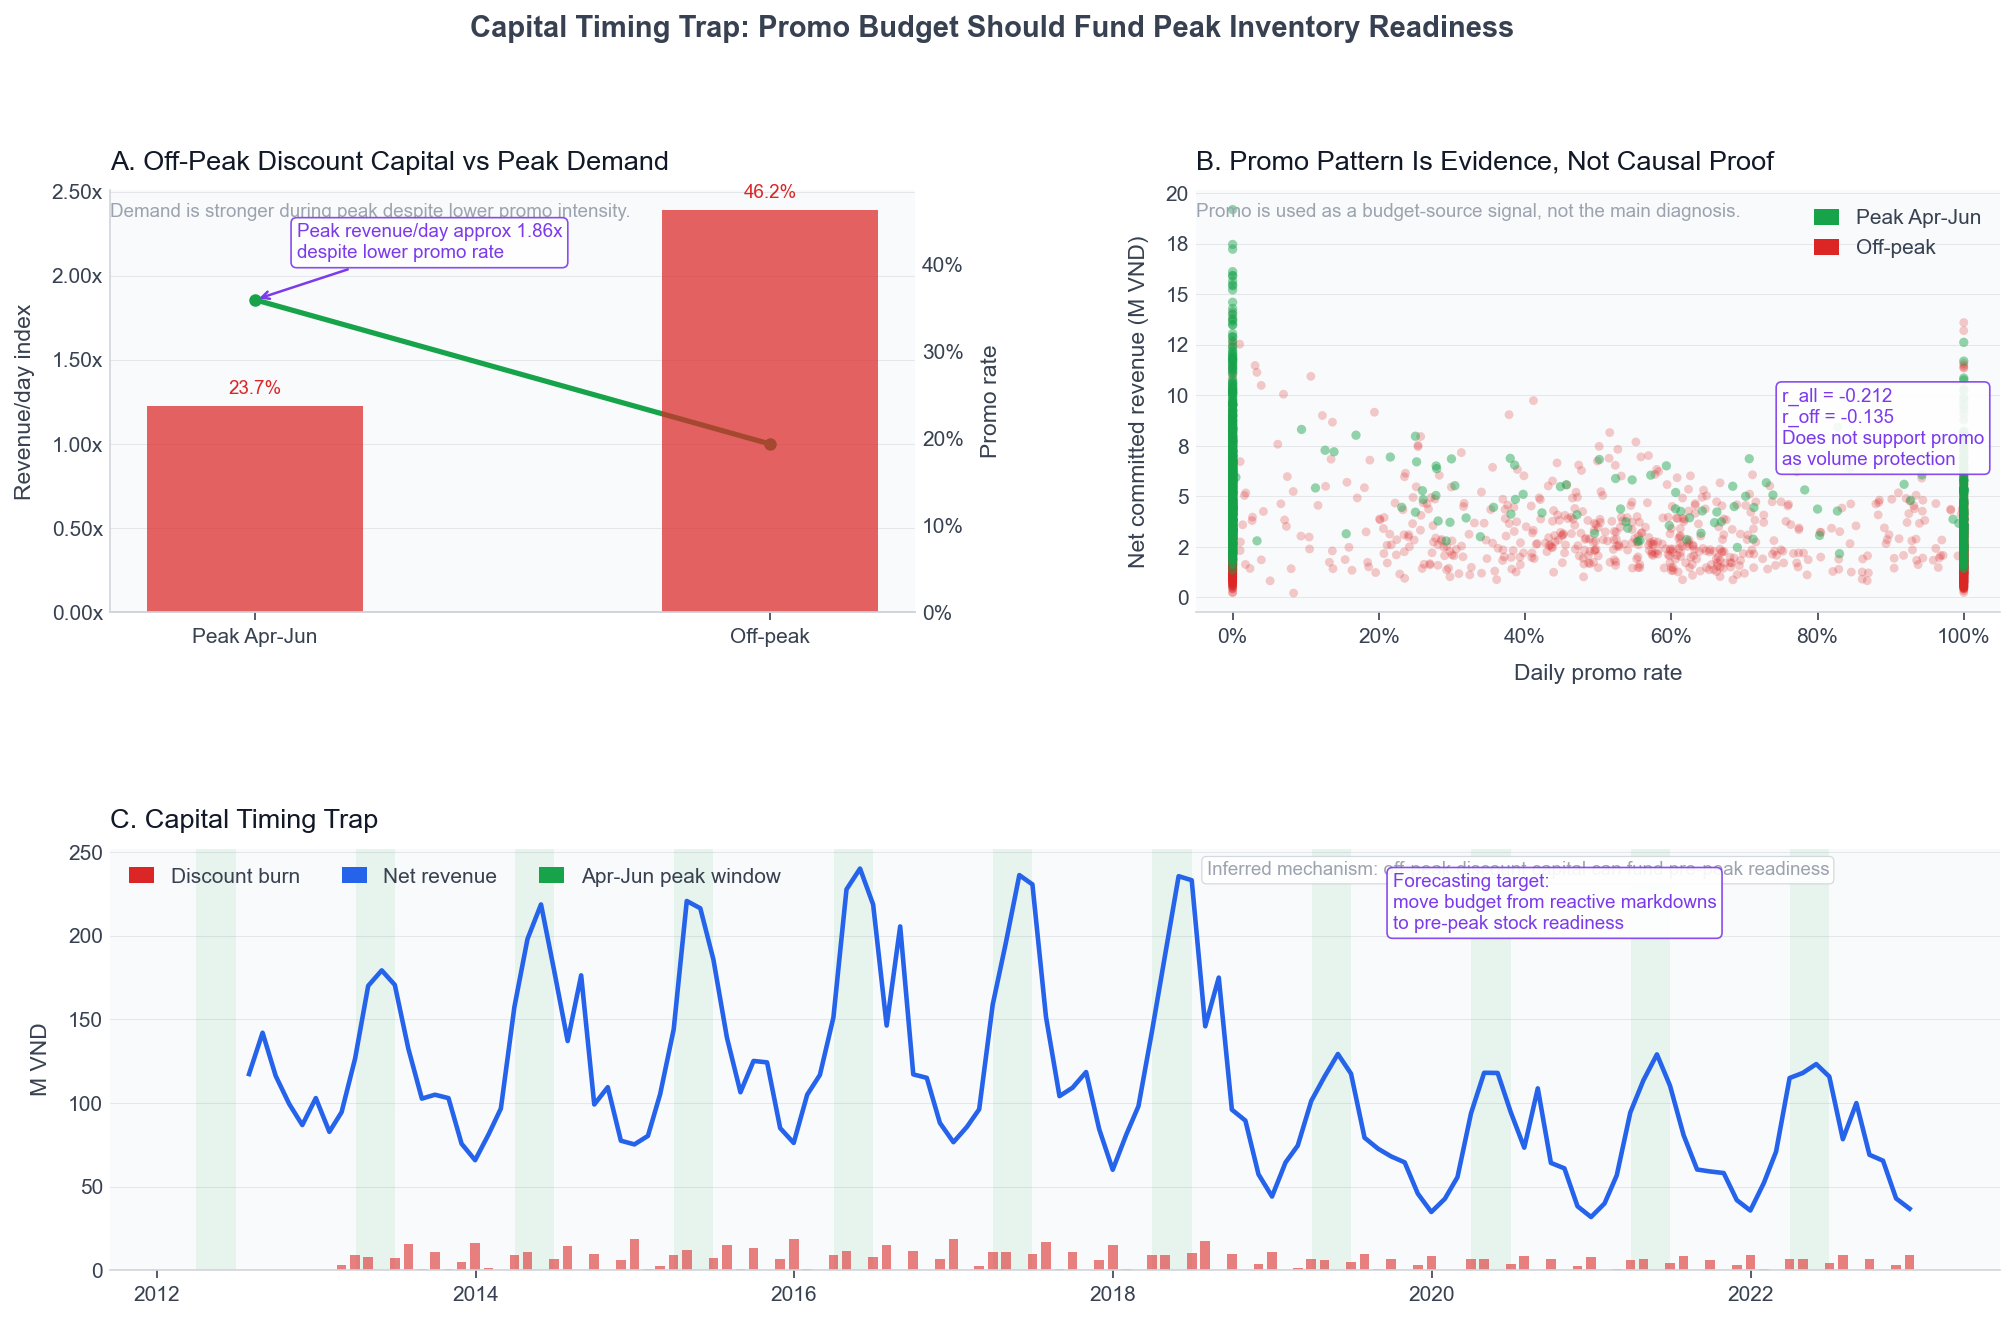

In [6]:
# CELL 4 - Composite Figure

from matplotlib import dates as mdates

fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 2, hspace=0.56, wspace=0.35)
fig.subplots_adjust(top=0.88, bottom=0.08, left=0.08, right=0.98)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, :])

# Panel A - Promo Is Heavier When Demand Is Lower.
x_labels = ['Peak Apr-Jun', 'Off-peak']
x = np.arange(len(x_labels))
rev_index = [revenue_day_ratio, 1.0]
promo_rates = [peak_period['promo_rate'], off_period['promo_rate']]

ax_a.plot(
    x, rev_index, marker='o', color=COLORS['emerald'], linewidth=2.5,
    label='Revenue/day index'
)
ax_a.set_xticks(x)
ax_a.set_xticklabels(x_labels)
ax_a.set_ylim(0, max(rev_index) * 1.35)
style_ax(
    ax_a,
    title='A. Off-Peak Discount Capital vs Peak Demand',
    subtitle='',
    xlabel='',
    ylabel='Revenue/day index',
    yformat='{x:.2f}x'
)
ax_a.text(
    0.0, 0.97,
    'Demand is stronger during peak despite lower promo intensity.',
    transform=ax_a.transAxes, ha='left', va='top', fontsize=9, color=CLR_MUTED
)

ax_a2 = ax_a.twinx()
bars = ax_a2.bar(x, promo_rates, width=0.42, color=COLORS['red'], alpha=0.72, label='Promo rate')
annotate_bar(ax_a2, bars, fmt='{:.1%}', offset=4, color=COLORS['red'])
ax_a2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0%}"))
ax_a2.set_ylabel('Promo rate', color=CLR_LABEL)
ax_a2.tick_params(axis='y', colors=CLR_LABEL)
ax_a2.spines['right'].set_color(CLR_SPINE)
ax_a2.spines['top'].set_visible(False)
ax_a2.grid(False)

add_insight(
    ax_a,
    x=0,
    y=revenue_day_ratio,
    text=f"Peak revenue/day approx {revenue_day_ratio:.2f}x\ndespite lower promo rate",
    color=COLORS['violet']
)

# Panel B - Promo pattern as evidence, not causal proof.
peak_mask = daily['is_peak']
ax_b.scatter(
    daily.loc[~peak_mask, 'promo_rate'],
    daily.loc[~peak_mask, 'net_rev'] / 1e6,
    s=18, alpha=0.24, color=COLORS['red'], edgecolors='none', label='Off-peak'
)
ax_b.scatter(
    daily.loc[peak_mask, 'promo_rate'],
    daily.loc[peak_mask, 'net_rev'] / 1e6,
    s=20, alpha=0.45, color=COLORS['emerald'], edgecolors='none', label='Peak Apr-Jun'
)
ax_b.xaxis.set_major_formatter(FuncFormatter(lambda val, _: f"{val:.0%}"))
style_ax(
    ax_b,
    title='B. Promo Pattern Is Evidence, Not Causal Proof',
    subtitle='',
    xlabel='Daily promo rate',
    ylabel='Net committed revenue (M VND)',
    yformat='{x:,.0f}'
)
ax_b.text(
    0.0, 0.97,
    'Promo is used as a budget-source signal, not the main diagnosis.',
    transform=ax_b.transAxes, ha='left', va='top', fontsize=9, color=CLR_MUTED
)
make_legend(ax_b, ['Peak Apr-Jun', 'Off-peak'], [COLORS['emerald'], COLORS['red']], loc='upper right')
add_insight(
    ax_b,
    x=daily['promo_rate'].quantile(0.68),
    y=(daily['net_rev'] / 1e6).quantile(0.74),
    text=(
        f"r_all = {r_all:.3f}\n"
        f"r_off = {r_off:.3f}\n"
        "Does not support promo\nas volume protection"
    ),
    color=COLORS['violet'],
    arrow=False
)

# Panel C - Capital Timing Trap.
# pandas 3.x removed the legacy 'M' alias; keep month-end grouping portable.
monthly_agg = dict(
    net_rev=('net_line', 'sum'),
    discount_burn=('discount_amount', 'sum'),
    gross_profit=('gross_profit', 'sum'),
    promo_rate=('has_promo', 'mean'),
    orders=('order_id', 'nunique')
)
try:
    monthly = f.groupby(pd.Grouper(key='date', freq='M')).agg(**monthly_agg).reset_index()
except ValueError:
    monthly = f.groupby(pd.Grouper(key='date', freq='ME')).agg(**monthly_agg).reset_index()

for year in sorted(monthly['date'].dt.year.unique()):
    ax_c.axvspan(
        pd.Timestamp(year=year, month=4, day=1),
        pd.Timestamp(year=year, month=6, day=30),
        color=COLORS['emerald'], alpha=0.08, lw=0
    )

ax_c.bar(
    monthly['date'], monthly['discount_burn'] / 1e6,
    width=22, color=COLORS['red'], alpha=0.58, label='Discount burn'
)
ax_c.plot(
    monthly['date'], monthly['net_rev'] / 1e6,
    color=COLORS['blue'], linewidth=2.2, label='Net revenue'
)
ax_c.xaxis.set_major_formatter(FuncFormatter(lambda val, _: mdates.num2date(val).strftime('%Y') if val > 1 else ''))
style_ax(
    ax_c,
    title='C. Capital Timing Trap',
    subtitle='',
    xlabel='',
    ylabel='M VND',
    yformat='{x:,.0f}'
)
ax_c.text(
    0.58, 0.97,
    'Inferred mechanism: off-peak discount capital can fund pre-peak readiness',
    transform=ax_c.transAxes, ha='left', va='top', fontsize=9, color=CLR_MUTED,
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor=CLR_SPINE, linewidth=0.6, alpha=0.9)
)
make_legend(ax_c, ['Discount burn', 'Net revenue', 'Apr-Jun peak window'], [COLORS['red'], COLORS['blue'], COLORS['emerald']], loc='upper left', ncol=3)
add_insight(
    ax_c,
    x=monthly['date'].iloc[int(len(monthly) * 0.66)],
    y=(monthly['net_rev'] / 1e6).quantile(0.88),
    text='Forecasting target:\nmove budget from reactive markdowns\nto pre-peak stock readiness',
    color=COLORS['violet'],
    arrow=False
)

plt.suptitle(
    'Capital Timing Trap: Promo Budget Should Fund Peak Inventory Readiness',
    fontsize=14, fontweight='bold', y=1.01, color=CLR_LABEL
)
plt.savefig(OUT / 'fig_seasonal_capital_misallocation.png', bbox_inches='tight', dpi=300)
plt.show()


,period,stockout_days,stockout_sku_months,sku_months,avg_fill_rate,units_sold,stock_on_hand,months,stockout_days_per_month,stockout_sku_months_per_month,stockout_days_per_sku_month,stockout_sku_month_rate
0,Peak Apr-Jun,"18,900","10,482","15,350",95.90%,"314,308","2,856,195",30,630.0,349.4,1.231,68.3%
1,Off-peak,"51,025","30,089","44,897",96.21%,"614,566","8,548,469",96,531.5,313.4,1.136,67.0%


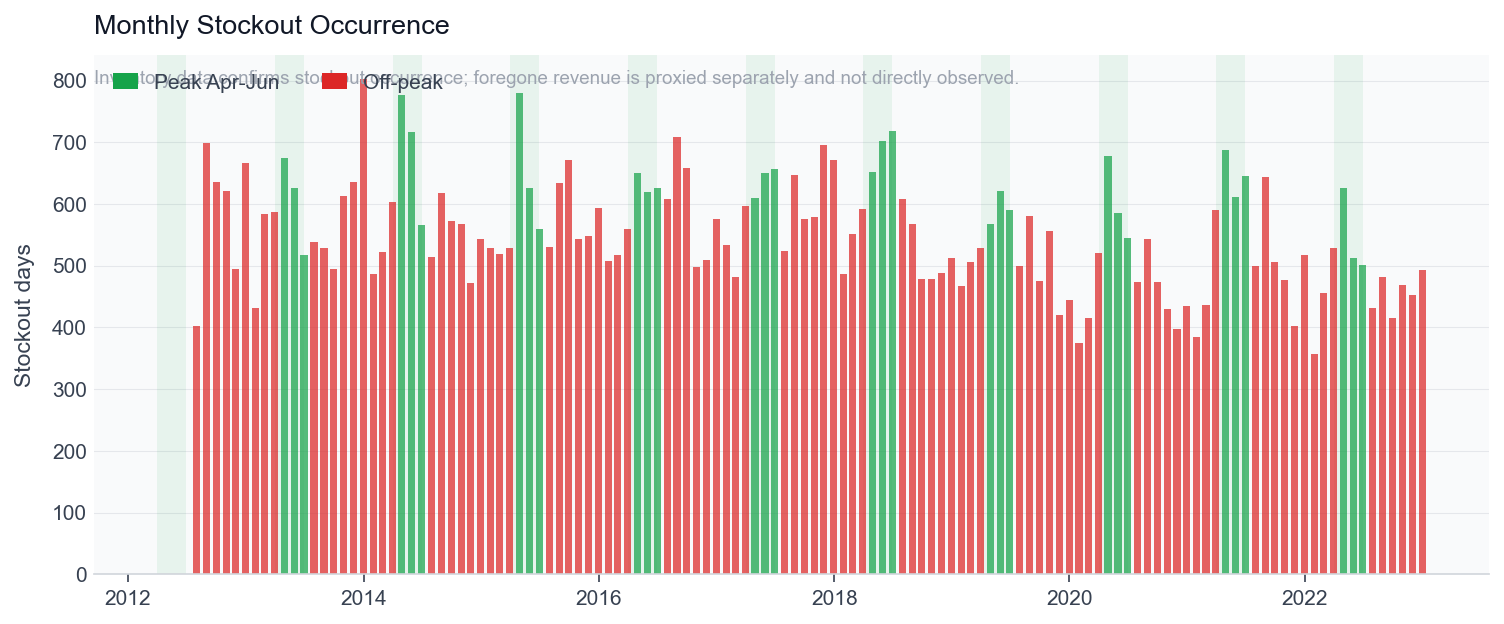

Inventory data confirms stockout occurrence; foregone revenue is proxied separately and not directly observed.


In [7]:
# CELL 5 - Stockout Occurrence Evidence

from matplotlib import dates as mdates

# Default implementation: stockout occurrence only. Foregone demand is proxied separately in Cell 7.
monthly_stockout = inv.groupby(['year', 'month']).agg(
    stockout_days=('stockout_days', 'sum'),
    stockout_sku_months=('stockout_flag', 'sum'),
    avg_fill_rate=('fill_rate', 'mean'),
    units_sold=('units_sold', 'sum'),
    stock_on_hand=('stock_on_hand', 'sum')
).reset_index()

monthly_stockout['is_peak'] = monthly_stockout['month'].isin([4, 5, 6])
monthly_stockout['date'] = pd.to_datetime(dict(
    year=monthly_stockout['year'],
    month=monthly_stockout['month'],
    day=1
)) + pd.offsets.MonthEnd(0)

stockout_period = inv.groupby('is_peak').agg(
    stockout_days=('stockout_days', 'sum'),
    stockout_sku_months=('stockout_flag', 'sum'),
    sku_months=('product_id', 'size'),
    avg_fill_rate=('fill_rate', 'mean'),
    units_sold=('units_sold', 'sum'),
    stock_on_hand=('stock_on_hand', 'sum'),
    months=('snapshot_date', 'nunique')
).reset_index()
stockout_period['period'] = np.where(stockout_period['is_peak'], 'Peak Apr-Jun', 'Off-peak')
stockout_period['stockout_days_per_month'] = stockout_period['stockout_days'] / stockout_period['months']
stockout_period['stockout_sku_months_per_month'] = stockout_period['stockout_sku_months'] / stockout_period['months']
stockout_period['stockout_days_per_sku_month'] = stockout_period['stockout_days'] / stockout_period['sku_months']
stockout_period['stockout_sku_month_rate'] = stockout_period['stockout_sku_months'] / stockout_period['sku_months']
stockout_period = stockout_period.sort_values('is_peak', ascending=False).reset_index(drop=True)

stockout_display = stockout_period.assign(
    stockout_days=lambda d: d['stockout_days'].map(lambda x: f"{x:,.0f}"),
    stockout_sku_months=lambda d: d['stockout_sku_months'].map(lambda x: f"{x:,.0f}"),
    sku_months=lambda d: d['sku_months'].map(lambda x: f"{x:,.0f}"),
    avg_fill_rate=lambda d: d['avg_fill_rate'].map(lambda x: f"{x:.2%}"),
    units_sold=lambda d: d['units_sold'].map(lambda x: f"{x:,.0f}"),
    stock_on_hand=lambda d: d['stock_on_hand'].map(lambda x: f"{x:,.0f}"),
    stockout_days_per_month=lambda d: d['stockout_days_per_month'].map(lambda x: f"{x:,.1f}"),
    stockout_sku_months_per_month=lambda d: d['stockout_sku_months_per_month'].map(lambda x: f"{x:,.1f}"),
    stockout_days_per_sku_month=lambda d: d['stockout_days_per_sku_month'].map(lambda x: f"{x:.3f}"),
    stockout_sku_month_rate=lambda d: d['stockout_sku_month_rate'].map(lambda x: f"{x:.1%}"),
)

display(stockout_display[[
    'period', 'stockout_days', 'stockout_sku_months', 'sku_months', 'avg_fill_rate',
    'units_sold', 'stock_on_hand', 'months',
    'stockout_days_per_month', 'stockout_sku_months_per_month',
    'stockout_days_per_sku_month', 'stockout_sku_month_rate'
]])

fig, ax = plt.subplots(figsize=(12, 4.5))
for year in sorted(monthly_stockout['year'].unique()):
    ax.axvspan(
        pd.Timestamp(year=year, month=4, day=1),
        pd.Timestamp(year=year, month=6, day=30),
        color=COLORS['emerald'], alpha=0.08, lw=0
    )

ax.bar(
    monthly_stockout['date'], monthly_stockout['stockout_days'],
    width=22,
    color=np.where(monthly_stockout['is_peak'], COLORS['emerald'], COLORS['red']),
    alpha=0.72
)
ax.xaxis.set_major_formatter(FuncFormatter(lambda val, _: mdates.num2date(val).strftime('%Y') if val > 1 else ''))
style_ax(
    ax,
    title='Monthly Stockout Occurrence',
    subtitle='',
    xlabel='',
    ylabel='Stockout days',
    yformat='{x:,.0f}'
)
ax.text(
    0.0, 0.97,
    'Inventory data confirms stockout occurrence; foregone revenue is proxied separately and not directly observed.',
    transform=ax.transAxes, ha='left', va='top', fontsize=9, color=CLR_MUTED
)
make_legend(ax, ['Peak Apr-Jun', 'Off-peak'], [COLORS['emerald'], COLORS['red']], loc='upper left', ncol=2)
plt.show()

print('Inventory data confirms stockout occurrence; foregone revenue is proxied separately and not directly observed.')


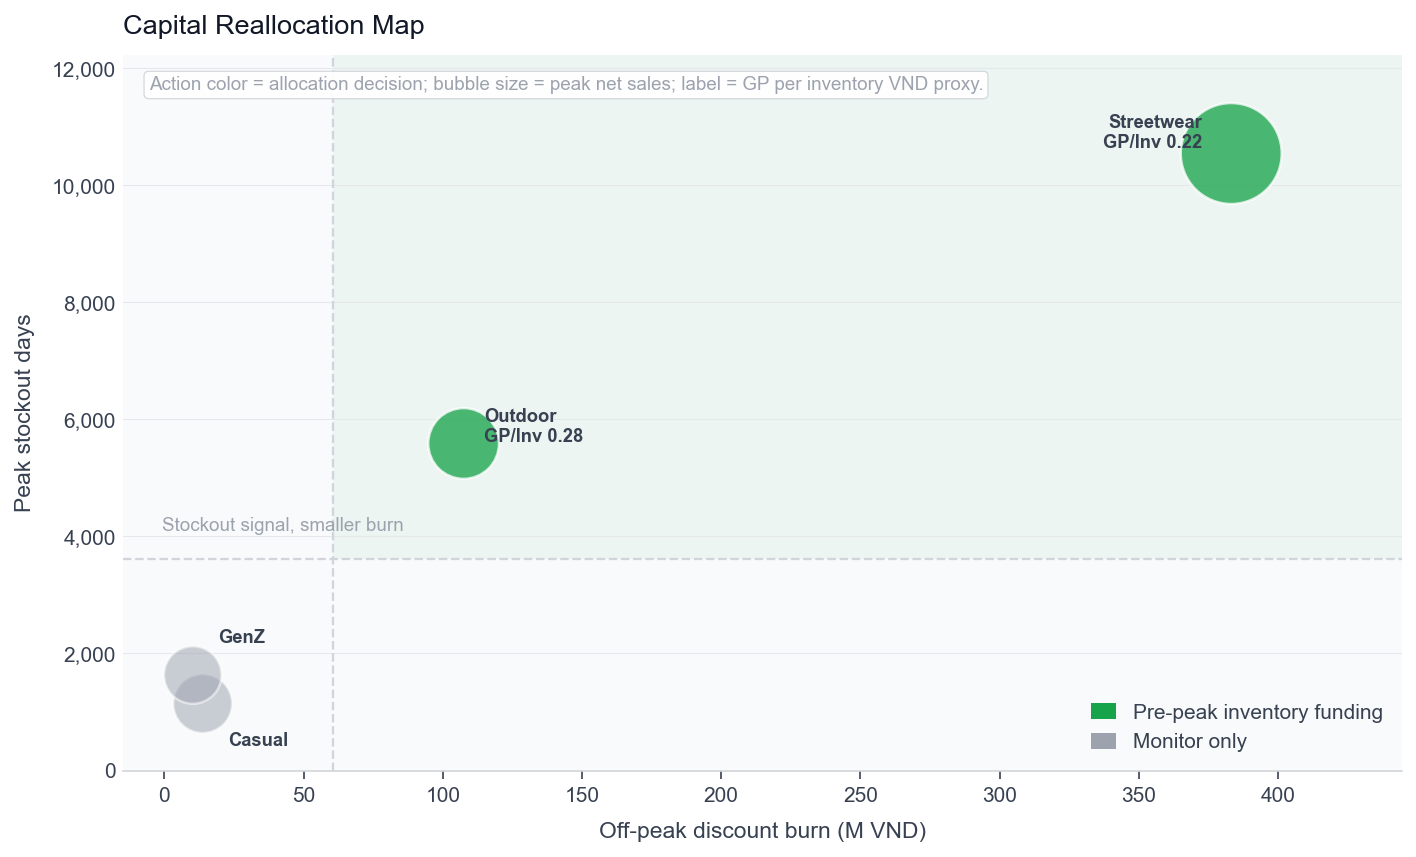

### Where to Redirect Capital

,category,offpeak_discount_burn,peak_net_sales,peak_gross_profit,peak_margin,peak_stockout_days,peak_stockout_days_per_sku_month,stockout_sku_month_rate,recoverable_gp_proxy,inventory_cogs_required_proxy,gp_per_inventory_vnd,priority_score,recommended_action
0,Streetwear,383.2M VND,"4,294.3M VND",624.6M VND,14.5%,"10,537",1.312,67.8%,45.6M VND,206.6M VND,0.221,85.0,Pre-peak inventory funding
1,Outdoor,107.5M VND,590.8M VND,94.9M VND,16.1%,"5,586",1.083,68.8%,4.3M VND,15.5M VND,0.279,62.5,Pre-peak inventory funding
2,GenZ,10.2M VND,117.3M VND,21.8M VND,18.6%,"1,632",1.292,70.2%,2.0M VND,5.2M VND,0.396,52.5,Monitor only
3,Casual,13.8M VND,145.6M VND,15.0M VND,10.3%,"1,145",1.269,67.3%,1.6M VND,6.9M VND,0.227,50.0,Monitor only


Priority candidates for pre-peak inventory funding: Streetwear, Outdoor.
The map identifies candidates; it does not prove stockout recovery or optimized budget size.


In [8]:
# CELL 6 - Capital Reallocation Map + Where to Redirect Capital

from matplotlib.colors import LinearSegmentedColormap

# Off-peak promo is treated as the budget source. The allocation target is peak inventory readiness.
offpeak_discount_burn = f.loc[~f['is_peak'], 'discount_amount'].sum()

# Stockout-capture margin recovery proxy.
# This is scenario-based, not observed realized impact. It estimates lost units from observed
# in-stock sales velocity and only counts positive-margin SKU-months as eligible for restocking.
sku_month_economics = f.groupby(['product_id', 'year', 'month']).agg(
    observed_units=('quantity', 'sum'),
    observed_gross_profit=('gross_profit', 'sum'),
    observed_cogs=('cogs_line', 'sum'),
).reset_index()
sku_month_economics['gp_per_unit'] = np.where(
    sku_month_economics['observed_units'].gt(0),
    sku_month_economics['observed_gross_profit'] / sku_month_economics['observed_units'],
    np.nan
)
sku_month_economics['cogs_per_unit'] = np.where(
    sku_month_economics['observed_units'].gt(0),
    sku_month_economics['observed_cogs'] / sku_month_economics['observed_units'],
    np.nan
)

product_peak_economics = f[f['is_peak']].groupby('product_id').agg(
    peak_units=('quantity', 'sum'),
    peak_gross_profit=('gross_profit', 'sum'),
    peak_cogs=('cogs_line', 'sum'),
).reset_index()
product_peak_economics['gp_per_unit_peak'] = np.where(
    product_peak_economics['peak_units'].gt(0),
    product_peak_economics['peak_gross_profit'] / product_peak_economics['peak_units'],
    np.nan
)
product_peak_economics['cogs_per_unit_peak'] = np.where(
    product_peak_economics['peak_units'].gt(0),
    product_peak_economics['peak_cogs'] / product_peak_economics['peak_units'],
    np.nan
)

product_all_economics = f.groupby('product_id').agg(
    all_units=('quantity', 'sum'),
    all_gross_profit=('gross_profit', 'sum'),
    all_cogs=('cogs_line', 'sum'),
).reset_index()
product_all_economics['gp_per_unit_all'] = np.where(
    product_all_economics['all_units'].gt(0),
    product_all_economics['all_gross_profit'] / product_all_economics['all_units'],
    np.nan
)
product_all_economics['cogs_per_unit_all'] = np.where(
    product_all_economics['all_units'].gt(0),
    product_all_economics['all_cogs'] / product_all_economics['all_units'],
    np.nan
)

peak_stockout_proxy = inv[inv['is_peak'] & inv['stockout_days'].gt(0)].copy()
peak_stockout_proxy['month_days'] = peak_stockout_proxy['snapshot_date'].dt.days_in_month
peak_stockout_proxy = peak_stockout_proxy.merge(
    sku_month_economics,
    on=['product_id', 'year', 'month'],
    how='left'
).merge(
    product_peak_economics[['product_id', 'gp_per_unit_peak', 'cogs_per_unit_peak']],
    on='product_id',
    how='left'
).merge(
    product_all_economics[['product_id', 'gp_per_unit_all', 'cogs_per_unit_all']],
    on='product_id',
    how='left'
).merge(
    products[['product_id', 'cogs']],
    on='product_id',
    how='left'
)

peak_stockout_proxy['gp_per_unit_recovery'] = (
    peak_stockout_proxy['gp_per_unit']
    .combine_first(peak_stockout_proxy['gp_per_unit_peak'])
    .combine_first(peak_stockout_proxy['gp_per_unit_all'])
)
peak_stockout_proxy['cogs_per_unit_recovery'] = (
    peak_stockout_proxy['cogs_per_unit']
    .combine_first(peak_stockout_proxy['cogs_per_unit_peak'])
    .combine_first(peak_stockout_proxy['cogs_per_unit_all'])
    .combine_first(peak_stockout_proxy['cogs'])
)
peak_stockout_proxy['observed_units'] = peak_stockout_proxy['observed_units'].fillna(0)
peak_stockout_proxy['in_stock_days_proxy'] = (
    peak_stockout_proxy['month_days'] - peak_stockout_proxy['stockout_days']
).clip(lower=1)
peak_stockout_proxy['lost_units_proxy'] = (
    peak_stockout_proxy['observed_units']
    / peak_stockout_proxy['in_stock_days_proxy']
    * peak_stockout_proxy['stockout_days']
)

recovery_pool = peak_stockout_proxy[
    peak_stockout_proxy['lost_units_proxy'].gt(0)
    & peak_stockout_proxy['gp_per_unit_recovery'].gt(0)
    & peak_stockout_proxy['cogs_per_unit_recovery'].gt(0)
].copy()
recovery_pool['recoverable_gp_100pct'] = (
    recovery_pool['lost_units_proxy'] * recovery_pool['gp_per_unit_recovery']
)
recovery_pool['inventory_cogs_100pct'] = (
    recovery_pool['lost_units_proxy'] * recovery_pool['cogs_per_unit_recovery']
)
recovery_pool['gp_per_inventory_vnd'] = (
    recovery_pool['recoverable_gp_100pct'] / recovery_pool['inventory_cogs_100pct']
)

# Category-level decision map.
offpeak_category = f[~f['is_peak']].groupby('category').agg(
    offpeak_discount_burn=('discount_amount', 'sum'),
    offpeak_net_sales=('net_line', 'sum'),
    offpeak_promo_rate=('has_promo', 'mean'),
).reset_index()

peak_category = f[f['is_peak']].groupby('category').agg(
    peak_net_sales=('net_line', 'sum'),
    peak_gross_profit=('gross_profit', 'sum'),
    peak_cogs=('cogs_line', 'sum'),
    peak_units=('quantity', 'sum'),
    peak_sku_count=('product_id', 'nunique'),
).reset_index()
peak_category['peak_margin'] = np.where(
    peak_category['peak_net_sales'].gt(0),
    peak_category['peak_gross_profit'] / peak_category['peak_net_sales'],
    np.nan
)

peak_inventory_category = inv[inv['is_peak']].groupby('category').agg(
    peak_stockout_days=('stockout_days', 'sum'),
    peak_stockout_sku_months=('stockout_flag', 'sum'),
    peak_sku_months=('product_id', 'size'),
    peak_units_sold_inventory=('units_sold', 'sum'),
).reset_index()
peak_inventory_category['peak_stockout_days_per_sku_month'] = np.where(
    peak_inventory_category['peak_sku_months'].gt(0),
    peak_inventory_category['peak_stockout_days'] / peak_inventory_category['peak_sku_months'],
    np.nan
)
peak_inventory_category['stockout_sku_month_rate'] = np.where(
    peak_inventory_category['peak_sku_months'].gt(0),
    peak_inventory_category['peak_stockout_sku_months'] / peak_inventory_category['peak_sku_months'],
    np.nan
)

recovery_category = recovery_pool.groupby('category').agg(
    recoverable_gp_proxy=('recoverable_gp_100pct', 'sum'),
    inventory_cogs_required_proxy=('inventory_cogs_100pct', 'sum'),
    recoverable_lost_units_proxy=('lost_units_proxy', 'sum'),
).reset_index()
recovery_category['gp_per_inventory_vnd'] = np.where(
    recovery_category['inventory_cogs_required_proxy'].gt(0),
    recovery_category['recoverable_gp_proxy'] / recovery_category['inventory_cogs_required_proxy'],
    np.nan
)

category_priority = offpeak_category.merge(peak_category, on='category', how='outer') \
    .merge(peak_inventory_category, on='category', how='outer') \
    .merge(recovery_category, on='category', how='left')

numeric_cols = [c for c in category_priority.columns if c != 'category']
category_priority[numeric_cols] = category_priority[numeric_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

score_cols = {
    'offpeak_discount_burn': 0.30,
    'peak_net_sales': 0.25,
    'peak_stockout_days_per_sku_month': 0.25,
    'gp_per_inventory_vnd': 0.20,
}
for col in score_cols:
    category_priority[f'{col}_rank'] = category_priority[col].rank(pct=True).fillna(0)
category_priority['priority_score'] = sum(
    category_priority[f'{col}_rank'] * weight for col, weight in score_cols.items()
) * 100

burn_threshold = category_priority['offpeak_discount_burn'].median()
demand_threshold = category_priority['peak_net_sales'].median()
return_hurdle = 0.15  # proxy gross profit per inventory VND; scenario guardrail, not optimized

positive_margin = category_priority['peak_margin'].gt(0)
observed_stockout = category_priority['peak_stockout_days'].gt(0)
meaningful_peak_demand = category_priority['peak_net_sales'].ge(demand_threshold)
high_gp_per_inventory = category_priority['gp_per_inventory_vnd'].ge(return_hurdle)
high_offpeak_burn = category_priority['offpeak_discount_burn'].ge(burn_threshold)

category_priority['recommended_action'] = np.select(
    [
        positive_margin & observed_stockout & meaningful_peak_demand & high_gp_per_inventory,
        high_offpeak_burn & (~positive_margin | ~observed_stockout | ~high_gp_per_inventory),
    ],
    [
        'Pre-peak inventory funding',
        'Promo guardrail',
    ],
    default='Monitor only'
)

where_to_redirect_capital = category_priority.sort_values('priority_score', ascending=False).reset_index(drop=True)

primary_candidates = where_to_redirect_capital.loc[
    where_to_redirect_capital['recommended_action'].eq('Pre-peak inventory funding'), 'category'
].tolist()
primary_candidate_text = ', '.join(primary_candidates[:3]) if primary_candidates else 'No category clears all allocation guardrails yet'

# Capital Reallocation Map.
plot_df = category_priority.copy()
plot_df['bubble_size'] = 450 + 1900 * np.sqrt(
    plot_df['peak_net_sales'] / max(plot_df['peak_net_sales'].max(), 1)
)

x_m = plot_df['offpeak_discount_burn'] / 1e6
y_vals = plot_df['peak_stockout_days']
x_threshold = burn_threshold / 1e6
y_threshold = category_priority['peak_stockout_days'].median()
x_min = x_m.min() - 25
x_max = x_m.max() * 1.16
y_pad = max((y_vals.max() - y_vals.min()) * 0.18, 0.03)
y_min = max(0, y_vals.min() - y_pad)
y_max = y_vals.max() + y_pad

action_colors = {
    'Pre-peak inventory funding': COLORS['emerald'],
    'Promo guardrail': COLORS['flame'],
    'Monitor only': CLR_MUTED,
}

fig, ax = plt.subplots(figsize=(11, 6.2))
ax.fill_between(
    [x_threshold, x_max], y_threshold, y_max,
    color=COLORS['emerald'], alpha=0.055, zorder=0
)
ax.axvline(x_threshold, color=CLR_SPINE, linestyle='--', linewidth=1.1, zorder=1)
ax.axhline(y_threshold, color=CLR_SPINE, linestyle='--', linewidth=1.1, zorder=1)

for action, action_df in plot_df.groupby('recommended_action', sort=False):
    ax.scatter(
        action_df['offpeak_discount_burn'] / 1e6,
        action_df['peak_stockout_days'],
        s=action_df['bubble_size'],
        color=action_colors.get(action, COLORS['blue']),
        alpha=0.76 if action == 'Pre-peak inventory funding' else 0.52,
        edgecolors='white',
        linewidth=1.2,
        label=action,
        zorder=3,
    )

style_ax(
    ax,
    title='Capital Reallocation Map',
    subtitle='',
    xlabel='Off-peak discount burn (M VND)',
    ylabel='Peak stockout days',
    yformat='{x:,.0f}'
)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xticks(np.arange(0, x_m.max() * 1.11, 50))

ax.text(
    x_min + (x_max - x_min) * 0.03,
    y_threshold + (y_max - y_min) * 0.035,
    'Stockout signal, smaller burn',
    color=CLR_MUTED,
    fontsize=9,
    ha='left',
    va='bottom'
)
label_offsets = {
    'Streetwear': (-14, 10, 'right', 'center'),
    'Outdoor': (10, 8, 'left', 'center'),
    'GenZ': (12, 18, 'left', 'center'),
    'Casual': (12, -18, 'left', 'center'),
}
for _, row in plot_df.sort_values('priority_score', ascending=False).head(min(5, len(plot_df))).iterrows():
    x_pos = row['offpeak_discount_burn'] / 1e6
    y_pos = row['peak_stockout_days']
    dx, dy, ha, va = label_offsets.get(row['category'], (8, 6, 'left', 'center'))
    if row['recommended_action'] == 'Pre-peak inventory funding':
        label = f"{row['category']}\nGP/Inv {row['gp_per_inventory_vnd']:.2f}"
    else:
        label = row['category']
    ax.annotate(
        label,
        (x_pos, y_pos),
        xytext=(dx, dy),
        textcoords='offset points',
        ha=ha,
        va=va,
        fontsize=8.8,
        color=CLR_LABEL,
        fontweight='bold',
        linespacing=1.15,
        zorder=4,
    )

legend_order = ['Pre-peak inventory funding', 'Promo guardrail', 'Monitor only']
legend_labels = [label for label in legend_order if label in set(plot_df['recommended_action'])]
legend_colors = [action_colors[label] for label in legend_labels]
make_legend(ax, legend_labels, legend_colors, loc='lower right')

ax.text(
    0.02, 0.97,
    'Action color = allocation decision; bubble size = peak net sales; label = GP per inventory VND proxy.',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    color=CLR_MUTED,
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor=CLR_SPINE, linewidth=0.6, alpha=0.92)
)
plt.savefig(OUT / 'fig_capital_reallocation_map.png', bbox_inches='tight', dpi=300)
plt.show()

priority_display = where_to_redirect_capital[[
    'category', 'offpeak_discount_burn', 'peak_net_sales', 'peak_gross_profit',
    'peak_margin', 'peak_stockout_days', 'peak_stockout_days_per_sku_month',
    'stockout_sku_month_rate', 'recoverable_gp_proxy', 'inventory_cogs_required_proxy',
    'gp_per_inventory_vnd', 'priority_score', 'recommended_action'
]].copy()

priority_display_formatted = priority_display.assign(
    offpeak_discount_burn=lambda d: d['offpeak_discount_burn'].map(lambda x: f"{x/1e6:,.1f}M VND"),
    peak_net_sales=lambda d: d['peak_net_sales'].map(lambda x: f"{x/1e6:,.1f}M VND"),
    peak_gross_profit=lambda d: d['peak_gross_profit'].map(lambda x: f"{x/1e6:,.1f}M VND"),
    peak_margin=lambda d: d['peak_margin'].map(lambda x: f"{x:.1%}"),
    peak_stockout_days=lambda d: d['peak_stockout_days'].map(lambda x: f"{x:,.0f}"),
    peak_stockout_days_per_sku_month=lambda d: d['peak_stockout_days_per_sku_month'].map(lambda x: f"{x:.3f}"),
    stockout_sku_month_rate=lambda d: d['stockout_sku_month_rate'].map(lambda x: f"{x:.1%}"),
    recoverable_gp_proxy=lambda d: d['recoverable_gp_proxy'].map(lambda x: f"{x/1e6:,.1f}M VND"),
    inventory_cogs_required_proxy=lambda d: d['inventory_cogs_required_proxy'].map(lambda x: f"{x/1e6:,.1f}M VND"),
    gp_per_inventory_vnd=lambda d: d['gp_per_inventory_vnd'].map(lambda x: f"{x:.3f}"),
    priority_score=lambda d: d['priority_score'].map(lambda x: f"{x:.1f}"),
)

display(Markdown('### Where to Redirect Capital'))
display(priority_display_formatted)

where_to_redirect_capital.to_csv(OUT / 'capital_reallocation_priority_candidates.csv', index=False)

print(f"Priority candidates for pre-peak inventory funding: {primary_candidate_text}.")
print("The map identifies candidates; it does not prove stockout recovery or optimized budget size.")


# CELL 7 - Allocation Rule

Redirect budget only to SKU/category candidates that satisfy all operating guardrails:

- Positive gross margin on the B-BIS committed basis.
- Observed peak stockout occurrence (`stockout_days` or `stockout_flag`).
- Meaningful peak demand or forecasted Apr-Jun uplift.
- High gross profit per inventory VND on a recovery proxy basis.
- Measurable holdout validation path before scaling.

The 20/30/40% redirect cases are funding envelopes for ranked candidates, not blanket budget moves. **30% is a conservative planning scenario, not an optimized result.**


In [9]:
# CELL 8 - Evidence Synthesis Table

stockout_peak = stockout_period.loc[stockout_period['is_peak']].iloc[0]
stockout_off = stockout_period.loc[~stockout_period['is_peak']].iloc[0]

candidate_evidence = primary_candidate_text if 'primary_candidate_text' in globals() else 'Capital Reallocation Map not yet computed'

evidence_synthesis = pd.DataFrame([
    {
        'Claim': 'Promo is concentrated off-peak',
        'Evidence': f"K3 basis: off-peak promo rate {promo_off_k3:.1%} vs peak {promo_peak_k3:.1%}; corr(promo_rate, net_rev) = {r_all:.3f}",
        'Strength': 'Confirmed pattern; correlation is not causal proof',
        'Report Language': 'Promotion identifies a mistimed off-peak budget pool, not a pricing diagnosis'
    },
    {
        'Claim': 'Peak demand is seasonal, not discount-driven',
        'Evidence': f"Apr-Jun revenue/day {revenue_ratio_k3:.2f}x and sessions/day {sessions_ratio_k3:.2f}x while promo rate is lower",
        'Strength': 'Confirmed pattern',
        'Report Language': 'Apr-Jun has stronger natural demand despite lower discount intensity; no channel-attribution claim is made'
    },
    {
        'Claim': 'Inventory constraint exists',
        'Evidence': f"Stockout days per SKU-month: peak {stockout_peak['stockout_days_per_sku_month']:.3f} vs off-peak {stockout_off['stockout_days_per_sku_month']:.3f}; stockout SKU-month rate {stockout_peak['stockout_sku_month_rate']:.1%} vs {stockout_off['stockout_sku_month_rate']:.1%}",
        'Strength': 'Observed for occurrence; intensity gap may be modest',
        'Report Language': 'Inventory data confirms observed stockout occurrence; foregone demand remains a proxy'
    },
    {
        'Claim': 'Capital timing trap',
        'Evidence': 'Synthesis of off-peak discount burn + Apr-Jun demand strength + peak stockout occurrence',
        'Strength': 'Inferred mechanism',
        'Report Language': 'The strategic issue is seasonal capital misallocation, not simply promotion inefficiency'
    },
    {
        'Claim': 'Redirect candidates identified',
        'Evidence': f"Capital Reallocation Map priority candidates: {candidate_evidence}",
        'Strength': 'New category-level decision map',
        'Report Language': 'Upper-right categories are candidates for pre-peak inventory funding, subject to guardrails'
    },
    {
        'Claim': 'Forecasting requirement',
        'Evidence': 'Allocation rule requires forecasted daily/weekly net committed demand by category/SKU before Apr-Jun',
        'Strength': 'Needed to operationalize capital allocation',
        'Report Language': 'Forecasting is the operating system for deciding which candidates receive redirected capital'
    },
])

display(evidence_synthesis)


,Claim,Evidence,Strength,Report Language
0,Promo is concentrated off-peak,K3 basis: off-peak promo rate 43.4% vs peak 23...,Confirmed pattern; correlation is not causal p...,Promotion identifies a mistimed off-peak budge...
1,"Peak demand is seasonal, not discount-driven",Apr-Jun revenue/day 1.81x and sessions/day 1.6...,Confirmed pattern,Apr-Jun has stronger natural demand despite lo...
2,Inventory constraint exists,Stockout days per SKU-month: peak 1.231 vs off...,Observed for occurrence; intensity gap may be ...,Inventory data confirms observed stockout occu...
3,Capital timing trap,Synthesis of off-peak discount burn + Apr-Jun ...,Inferred mechanism,The strategic issue is seasonal capital misall...
4,Redirect candidates identified,Capital Reallocation Map priority candidates: ...,New category-level decision map,Upper-right categories are candidates for pre-...
5,Forecasting requirement,Allocation rule requires forecasted daily/week...,Needed to operationalize capital allocation,Forecasting is the operating system for decidi...


In [10]:
# CELL 9 - Prescriptive Scenario Table

# Sensitivity table only: 20/30/40% redirect budgets are funding envelopes for ranked candidates.
offpeak_discount_burn = f.loc[~f['is_peak'], 'discount_amount'].sum()

sensitivity = pd.DataFrame({'Redirect share': [0.20, 0.30, 0.40]})
sensitivity['Reallocated budget'] = sensitivity['Redirect share'] * offpeak_discount_burn
sensitivity['Scenario role'] = np.select(
    [
        sensitivity['Redirect share'].eq(0.20),
        sensitivity['Redirect share'].eq(0.30),
        sensitivity['Redirect share'].eq(0.40),
    ],
    [
        'Lower funding envelope',
        'Conservative planning scenario',
        'Upper sensitivity envelope',
    ],
    default='Sensitivity bound'
)
sensitivity['Allocation logic'] = np.select(
    [
        sensitivity['Redirect share'].eq(0.20),
        sensitivity['Redirect share'].eq(0.30),
        sensitivity['Redirect share'].eq(0.40),
    ],
    [
        'Fund only the clearest ranked candidates after forecast check',
        'Planning envelope for positive-margin, stockout-risk, forecast-supported candidates',
        'Stress-test envelope if the candidate pool validates and stockout risk persists',
    ],
    default='Sensitivity bound'
)

central_redirect_budget = sensitivity.loc[
    sensitivity['Redirect share'].eq(0.30), 'Reallocated budget'
].iloc[0]
capture_envelope = sensitivity.loc[
    sensitivity['Redirect share'].isin([0.30, 0.40]), 'Reallocated budget'
]
capture_envelope_low = capture_envelope.min()
capture_envelope_high = capture_envelope.max()

margin_capture = pd.DataFrame({'Stockout capture rate': [0.20, 0.30, 0.40]})
margin_capture['Captured lost-unit proxy'] = (
    margin_capture['Stockout capture rate'] * recovery_pool['lost_units_proxy'].sum()
)
margin_capture['Inventory COGS required'] = (
    margin_capture['Stockout capture rate'] * recovery_pool['inventory_cogs_100pct'].sum()
)
margin_capture['Gross profit recovery proxy'] = (
    margin_capture['Stockout capture rate'] * recovery_pool['recoverable_gp_100pct'].sum()
)
margin_capture['Feasible under 30% redirect budget'] = (
    margin_capture['Inventory COGS required'] <= central_redirect_budget
)
margin_capture['Interpretation'] = 'Conservative proxy: uniform capture across eligible positive-margin peak stockout pool'

def allocate_recovery_by_budget(pool, budget):
    ranked = pool.sort_values('gp_per_inventory_vnd', ascending=False)
    remaining = budget
    captured_units = 0.0
    cogs_used = 0.0
    gp_recovered = 0.0
    for _, row in ranked.iterrows():
        required_cogs = row['inventory_cogs_100pct']
        if required_cogs <= 0 or remaining <= 0:
            continue
        take = min(1.0, remaining / required_cogs)
        captured_units += row['lost_units_proxy'] * take
        cogs_used += required_cogs * take
        gp_recovered += row['recoverable_gp_100pct'] * take
        remaining -= required_cogs * take
        if remaining <= 1e-6:
            break
    return pd.Series({
        'Captured lost-unit proxy': captured_units,
        'Inventory COGS used': cogs_used,
        'Gross profit recovery upper bound': gp_recovered,
        'Unused budget': max(remaining, 0.0),
    })

targeted_recovery = sensitivity.join(
    sensitivity['Reallocated budget'].apply(lambda budget: allocate_recovery_by_budget(recovery_pool, budget))
)
pool_lost_units = recovery_pool['lost_units_proxy'].sum()
targeted_recovery['Pool coverage'] = np.where(
    pool_lost_units > 0,
    targeted_recovery['Captured lost-unit proxy'] / pool_lost_units,
    0
)
targeted_recovery['Interpretation'] = 'Upper bound: budget-constrained allocation ranked by gross profit per inventory VND'

central_uniform_recovery = margin_capture.loc[
    margin_capture['Stockout capture rate'].eq(0.30), 'Gross profit recovery proxy'
].iloc[0]
uniform_recovery_low = margin_capture['Gross profit recovery proxy'].min()
uniform_recovery_high = margin_capture['Gross profit recovery proxy'].max()
central_targeted_recovery = targeted_recovery.loc[
    targeted_recovery['Redirect share'].eq(0.30), 'Gross profit recovery upper bound'
].iloc[0]
targeted_recovery_low = targeted_recovery['Gross profit recovery upper bound'].min()
targeted_recovery_high = targeted_recovery['Gross profit recovery upper bound'].max()

sensitivity_display = sensitivity.assign(
    **{
        'Redirect share': sensitivity['Redirect share'].map(lambda x: f"{x:.0%}"),
        'Reallocated budget': sensitivity['Reallocated budget'].map(lambda x: f"{x/1e6:,.1f}M VND"),
    }
)
display(sensitivity_display[['Redirect share', 'Reallocated budget', 'Scenario role', 'Allocation logic']])

margin_capture_display = margin_capture.assign(
    **{
        'Stockout capture rate': margin_capture['Stockout capture rate'].map(lambda x: f"{x:.0%}"),
        'Captured lost-unit proxy': margin_capture['Captured lost-unit proxy'].map(lambda x: f"{x:,.0f}"),
        'Inventory COGS required': margin_capture['Inventory COGS required'].map(lambda x: f"{x/1e6:,.1f}M VND"),
        'Gross profit recovery proxy': margin_capture['Gross profit recovery proxy'].map(lambda x: f"{x/1e6:,.1f}M VND"),
        'Feasible under 30% redirect budget': margin_capture['Feasible under 30% redirect budget'].map(lambda x: 'Yes' if x else 'No'),
    }
)
display(margin_capture_display)

targeted_recovery_display = targeted_recovery.assign(
    **{
        'Redirect share': targeted_recovery['Redirect share'].map(lambda x: f"{x:.0%}"),
        'Reallocated budget': targeted_recovery['Reallocated budget'].map(lambda x: f"{x/1e6:,.1f}M VND"),
        'Captured lost-unit proxy': targeted_recovery['Captured lost-unit proxy'].map(lambda x: f"{x:,.0f}"),
        'Inventory COGS used': targeted_recovery['Inventory COGS used'].map(lambda x: f"{x/1e6:,.1f}M VND"),
        'Gross profit recovery upper bound': targeted_recovery['Gross profit recovery upper bound'].map(lambda x: f"{x/1e6:,.1f}M VND"),
        'Unused budget': targeted_recovery['Unused budget'].map(lambda x: f"{x/1e6:,.1f}M VND"),
        'Pool coverage': targeted_recovery['Pool coverage'].map(lambda x: f"{x:.1%}"),
    }
)
display(targeted_recovery_display[[
    'Redirect share', 'Reallocated budget', 'Captured lost-unit proxy',
    'Inventory COGS used', 'Gross profit recovery upper bound',
    'Unused budget', 'Pool coverage', 'Scenario role', 'Interpretation'
]])

scenario_guardrails = pd.DataFrame({
    'Scenario item': [
        '20/30/40% redirect budget',
        '30% planning scenario',
        'Uniform capture recovery',
        'Targeted recovery',
        'Model caveat',
    ],
    'Value': [
        f"{sensitivity['Reallocated budget'].min()/1e6:,.1f}-{sensitivity['Reallocated budget'].max()/1e6:,.1f}M VND",
        f"{central_redirect_budget/1e6:,.1f}M VND",
        f"{uniform_recovery_low/1e6:,.1f}-{uniform_recovery_high/1e6:,.1f}M VND gross profit proxy; central 30% capture = {central_uniform_recovery/1e6:,.1f}M VND",
        f"{targeted_recovery_low/1e6:,.1f}-{targeted_recovery_high/1e6:,.1f}M VND gross profit upper bound; central 30% redirect = {central_targeted_recovery/1e6:,.1f}M VND",
        'The model sizes the opportunity; it does not prove realized uplift.',
    ],
    'Status': [
        'Funding envelope for ranked candidates, not blanket reallocation',
        '30% is a conservative planning scenario, not an optimized result.',
        'Conservative proxy across eligible positive-margin stockout demand',
        'Budget-constrained and ranked by gross profit per inventory VND',
        'Requires holdout validation, captured-unit measurement, and margin validation',
    ]
})
display(scenario_guardrails)

print('30% is a conservative planning scenario, not an optimized result.')
print('The model sizes the opportunity; it does not prove realized uplift.')
print('Recovery estimates are proxy and scenario-based: positive-margin peak stockout SKU-months only.')


,Redirect share,Reallocated budget,Scenario role,Allocation logic
0,20%,102.9M VND,Lower funding envelope,Fund only the clearest ranked candidates after...
1,30%,154.4M VND,Conservative planning scenario,"Planning envelope for positive-margin, stockou..."
2,40%,205.9M VND,Upper sensitivity envelope,Stress-test envelope if the candidate pool val...


,Stockout capture rate,Captured lost-unit proxy,Inventory COGS required,Gross profit recovery proxy,Feasible under 30% redirect budget,Interpretation
0,20%,"10,554",46.8M VND,10.7M VND,Yes,Conservative proxy: uniform capture across eli...
1,30%,"15,831",70.2M VND,16.1M VND,Yes,Conservative proxy: uniform capture across eli...
2,40%,"21,108",93.6M VND,21.4M VND,Yes,Conservative proxy: uniform capture across eli...


,Redirect share,Reallocated budget,Captured lost-unit proxy,Inventory COGS used,Gross profit recovery upper bound,Unused budget,Pool coverage,Scenario role,Interpretation
0,20%,102.9M VND,"29,451",102.9M VND,45.1M VND,0.0M VND,55.8%,Lower funding envelope,Upper bound: budget-constrained allocation ran...
1,30%,154.4M VND,"39,390",154.4M VND,50.0M VND,0.0M VND,74.6%,Conservative planning scenario,Upper bound: budget-constrained allocation ran...
2,40%,205.9M VND,"47,981",205.9M VND,52.6M VND,0.0M VND,90.9%,Upper sensitivity envelope,Upper bound: budget-constrained allocation ran...


,Scenario item,Value,Status
0,20/30/40% redirect budget,102.9-205.9M VND,"Funding envelope for ranked candidates, not bl..."
1,30% planning scenario,154.4M VND,"30% is a conservative planning scenario, not a..."
2,Uniform capture recovery,10.7-21.4M VND gross profit proxy; central 30%...,Conservative proxy across eligible positive-ma...
3,Targeted recovery,45.1-52.6M VND gross profit upper bound; centr...,Budget-constrained and ranked by gross profit ...
4,Model caveat,The model sizes the opportunity; it does not p...,"Requires holdout validation, captured-unit mea..."


30% is a conservative planning scenario, not an optimized result.
The model sizes the opportunity; it does not prove realized uplift.
Recovery estimates are proxy and scenario-based: positive-margin peak stockout SKU-months only.


# CELL 10 - Forecasting Bridge

## Forecasting As The Operating System

Forecasting is not a technical add-on. It is the operating system that decides which category/SKU receives redirected capital before Apr-Jun demand arrives.

**Forecast target:** daily or weekly net committed demand by category/SKU on the B-BIS fulfilled basis. Returned orders remain included for demand and inventory planning; refunds are handled separately.

**Business use:** pre-peak inventory budget allocation, promo guardrails for weak off-peak periods, and safety stock planning for Apr-Jun.

**Allocation workflow:** forecast Apr-Jun uplift, rank candidates by positive margin, observed stockout risk, demand scale, and gross profit per inventory VND, then fund only the candidates with a measurable holdout validation path.

**KPIs:** peak stockout rate, captured units, net committed margin, off-peak discount burn, and gross profit per inventory VND.


In [11]:
# CELL 11 - Report Snippet
# Numbers aligned to K3 basis (verified in Cell 3B):
#   Promo rate  : discount_amount > 0, committed lines, monthly line-weighted mean -> grand mean
#   Revenue     : sales.Revenue gross all-status, monthly daily-mean -> grand mean (x1.81)
#   Sessions    : web_traffic.sessions daily mean per month -> grand mean (x1.68)
#   Correlation : B-BIS committed net basis (Cell 3), evidence pattern only
#   Scenario    : off-peak B-BIS committed discount burn + stockout-capture proxy (Cells 6 and 9)

candidate_phrase = primary_candidate_text if 'primary_candidate_text' in globals() else 'ranked category candidates'

snippet = f"""
**VI. Capital Timing Trap: Promo Budget Should Fund Peak Inventory Readiness**

This is not a pricing analysis. Promotion is used as a signal of mistimed capital: off-peak months carry a higher promo rate, about **{promo_off_k3:.0%}** versus **{promo_peak_k3:.0%}** in Apr-Jun on the K3 basis, and the promo-rate / net-revenue correlation is only an evidence pattern (**r ≈ {r_all:.2f}**), not causal proof.

Apr-Jun demand is stronger despite lower promo intensity. Revenue per day is about **{revenue_ratio_k3:.2f}x** off-peak and sessions are **{sessions_ratio_k3:.2f}x** higher, so the strategic issue is seasonal capital misallocation: discount budget is spent when demand is weaker, while peak demand needs readiness.

Inventory data shows observed stockout occurrence in peak months, while the Capital Reallocation Map identifies **{candidate_phrase}** as category-level candidates that combine off-peak discount burn, peak demand, stockout risk, and positive margin economics. The **30%** case is a conservative planning scenario, not an optimized result, sizing about **{central_redirect_budget/1e6:,.0f}M VND** as a funding envelope for ranked pre-peak inventory candidates.

Forecasting is the operating system for allocation: forecast daily/weekly net committed demand by category/SKU, then redirect capital only to positive-margin, observed-stockout, forecast-supported candidates with high gross profit per inventory VND and clear promo guardrails.

The recovery model is proxy and scenario-based. It sizes the opportunity; it does not prove realized uplift. Captured units, stockout elasticity, gross margin, and holdout validation are required before scaling.
"""

print(snippet)



**VI. Capital Timing Trap: Promo Budget Should Fund Peak Inventory Readiness**

This is not a pricing analysis. Promotion is used as a signal of mistimed capital: off-peak months carry a higher promo rate, about **43%** versus **24%** in Apr-Jun on the K3 basis, and the promo-rate / net-revenue correlation is only an evidence pattern (**r ≈ -0.21**), not causal proof.

Apr-Jun demand is stronger despite lower promo intensity. Revenue per day is about **1.81x** off-peak and sessions are **1.68x** higher, so the strategic issue is seasonal capital misallocation: discount budget is spent when demand is weaker, while peak demand needs readiness.

Inventory data shows observed stockout occurrence in peak months, while the Capital Reallocation Map identifies **Streetwear, Outdoor** as category-level candidates that combine off-peak discount burn, peak demand, stockout risk, and positive margin economics. The **30%** case is a conservative planning scenario, not an optimized result, sizing a